# Heart Disease Prediction — Advanced Analysis, Statistical Validation & Feature Engineering
### AnalystLab Africa — Data Science Internship, Week 3

This notebook continues directly from the Week 2 cleaned dataset (`data/heart_week2_cleaned.csv`,
917 rows). It does **not** repeat Week 2 cleaning — it builds on it with deeper EDA, statistical
hypothesis testing, further feature engineering, feature evaluation, and a refined final
modelling dataset.

## Part 1 — Project Continuity Summary

**Business problem:** AnalystLab Africa's healthcare client wants to identify patients likely to
have or develop heart disease from routine clinical measurements, to support earlier referral and
preventive care.

**Project objective:** Prepare and analyze the Heart Failure Prediction dataset (918 patients) to
eventually train a classifier that flags at-risk patients.

**Target variable:** `HeartDisease` (1 = disease present, 0 = normal), confirmed in Week 1/2 —
roughly 55% positive / 45% negative, a workable class balance.

**Key findings from Week 1 (EDA):** Established risk indicators (chest pain type, exercise-induced
angina, ST slope, max heart rate) showed visible separation between the two HeartDisease groups.
Cholesterol and RestingBP contained implausible zero values worth investigating further.

**Major data-quality issues identified in Week 1:** `RestingBP` and `Cholesterol` both contained
values of 0, which is not physiologically possible — a disguised form of missing data rather than
a true reading.

**Major cleaning/preprocessing actions completed in Week 2:** Dropped 1 row with `RestingBP == 0`;
imputed `Cholesterol == 0` (~19% of rows) with the per-class median; engineered `AgeGroup`,
`HR_Reserve`, and `BP_Category`; encoded categoricals and scaled continuous features into a
first machine-learning-ready dataset.

**Remaining questions for Week 3:** Are the visible group differences (e.g. Cholesterol,
MaxHR, Oldpeak by HeartDisease) statistically significant, or could they be due to chance? Do the
Week 2 engineered features actually carry independent signal, or are they redundant with the
originals? Are there further meaningful features to engineer using what Week 1–2 revealed?

## Part 2 — Advanced Exploratory Data Analysis
### 2.1 Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('data/heart_week2_cleaned.csv')
print(f"Loaded Week 2 cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded Week 2 cleaned dataset: 917 rows, 15 columns


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,HR_Reserve,BP_Category
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0,<40,8,Stage2_Hypertension
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1,40-50,15,Stage2_Hypertension
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0,<40,85,Stage1_Hypertension
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1,40-50,64,Stage1_Hypertension
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0,50-60,44,Stage2_Hypertension


### 2.2 Numerical Analysis — Distributions, Skewness & Variability

In [2]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HR_Reserve']
stats_summary = df[numeric_cols].agg(['mean', 'std', 'skew']).T
stats_summary.columns = ['Mean', 'Std Dev', 'Skewness']
stats_summary

,Mean,Std Dev,Skewness
Age,53.509269,9.437636,-0.195322
RestingBP,132.540894,17.999749,0.607195
Cholesterol,244.573610,53.385261,1.372867
MaxHR,136.789531,25.467129,-0.142459
Oldpeak,0.886696,1.066960,1.024545
HR_Reserve,29.701200,23.534703,0.247646


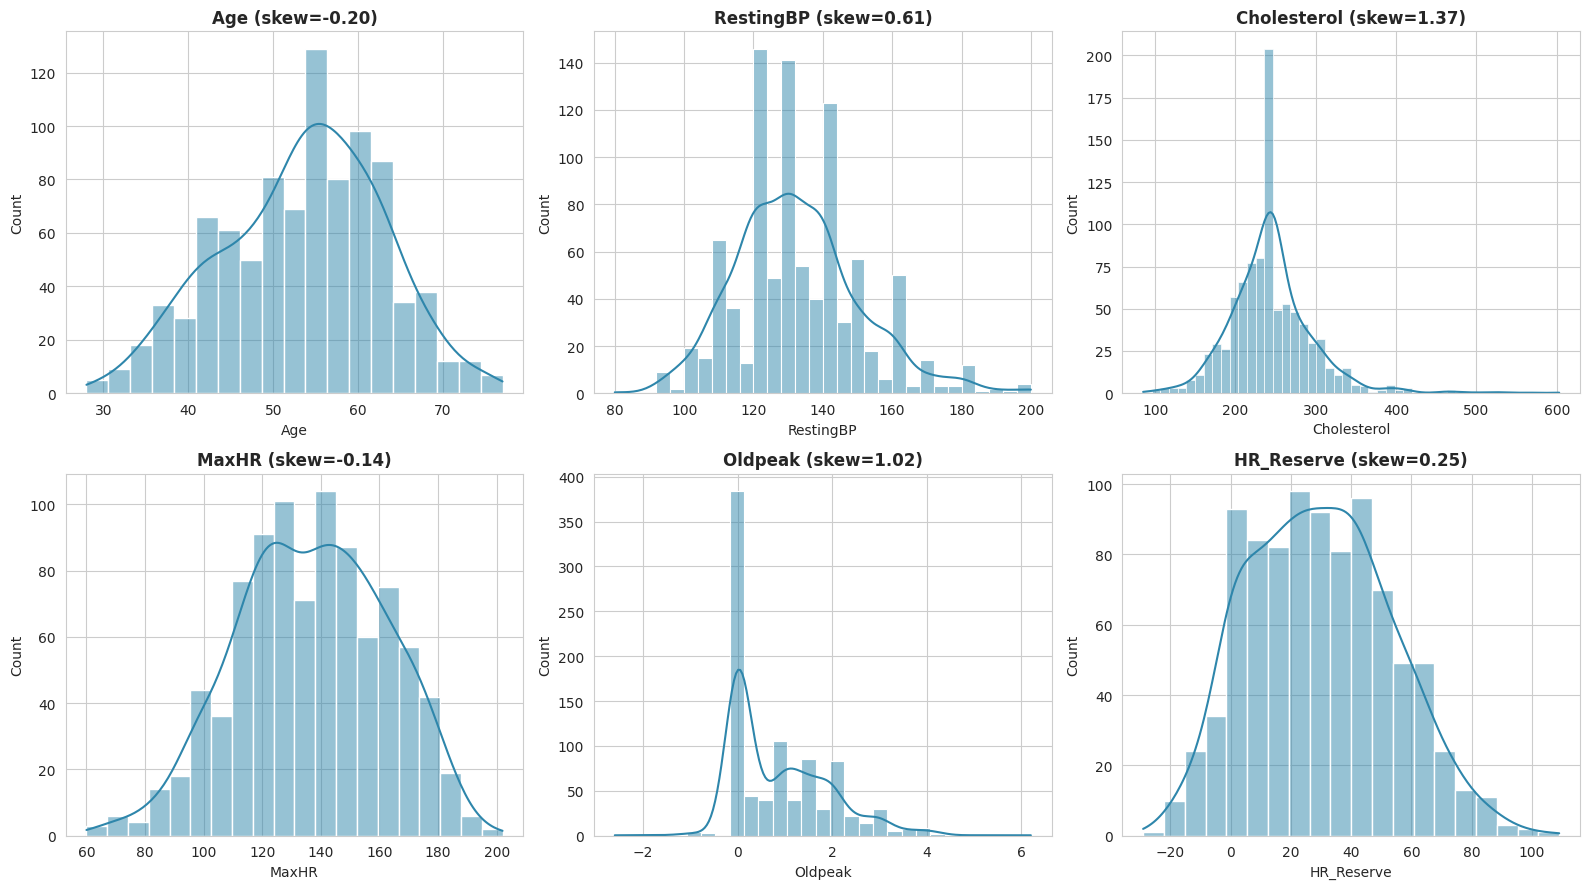

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#2E86AB')
    ax.set_title(f'{col} (skew={df[col].skew():.2f})', fontweight='bold')
plt.tight_layout()
plt.savefig('figs/w3_01_distributions.png', dpi=110)
plt.show()

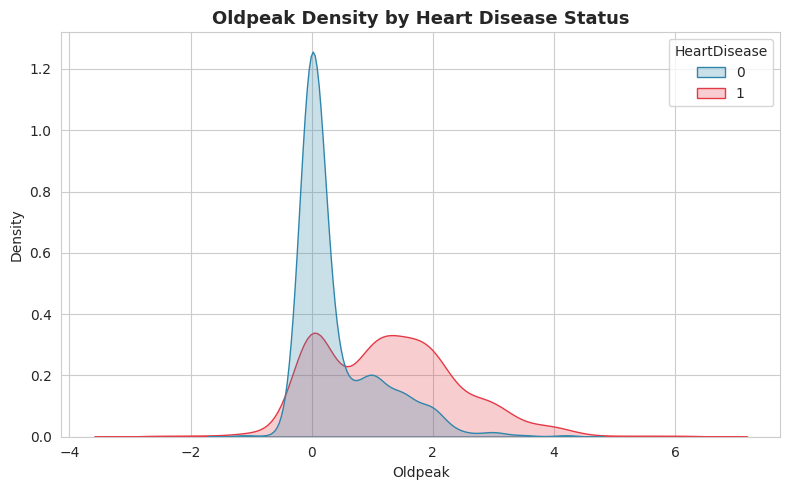

In [4]:
fig, ax = plt.subplots(figsize=(8,5))
sns.kdeplot(data=df, x='Oldpeak', hue='HeartDisease', fill=True,
            palette=['#2E86AB','#E63946'], common_norm=False, ax=ax)
ax.set_title('Oldpeak Density by Heart Disease Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/w3_02_oldpeak_density.png', dpi=110)
plt.show()

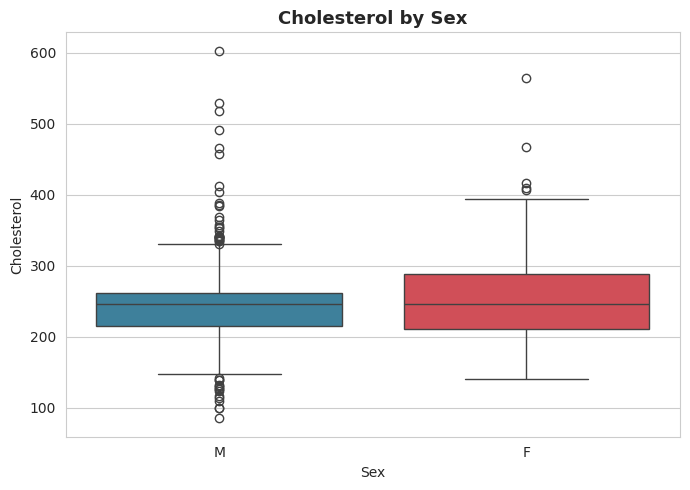

In [5]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df, x='Sex', y='Cholesterol', hue='Sex', palette=['#2E86AB','#E63946'], legend=False, ax=ax)
ax.set_title('Cholesterol by Sex', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/w3_03_chol_by_sex.png', dpi=110)
plt.show()

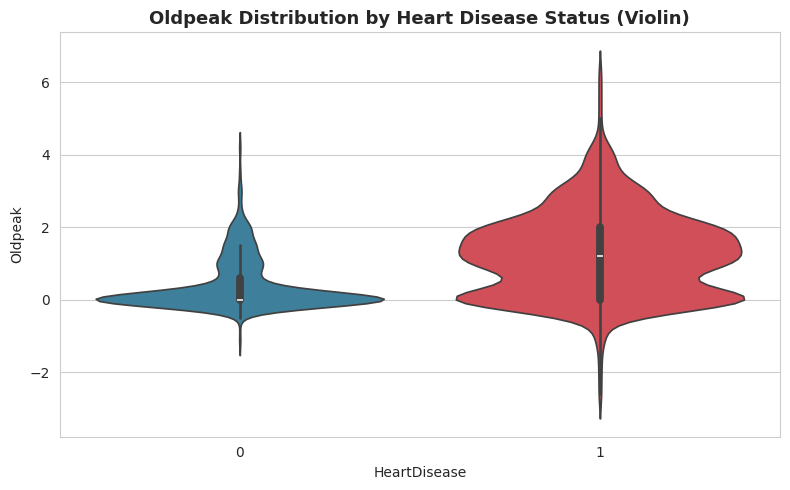

In [6]:
fig, ax = plt.subplots(figsize=(8,5))
sns.violinplot(data=df, x='HeartDisease', y='Oldpeak', hue='HeartDisease',
               palette=['#2E86AB','#E63946'], legend=False, ax=ax)
ax.set_title('Oldpeak Distribution by Heart Disease Status (Violin)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/w3_04_oldpeak_violin.png', dpi=110)
plt.show()

Skewness check — Age: -0.2 | Cholesterol: 1.37 | Oldpeak: 1.02


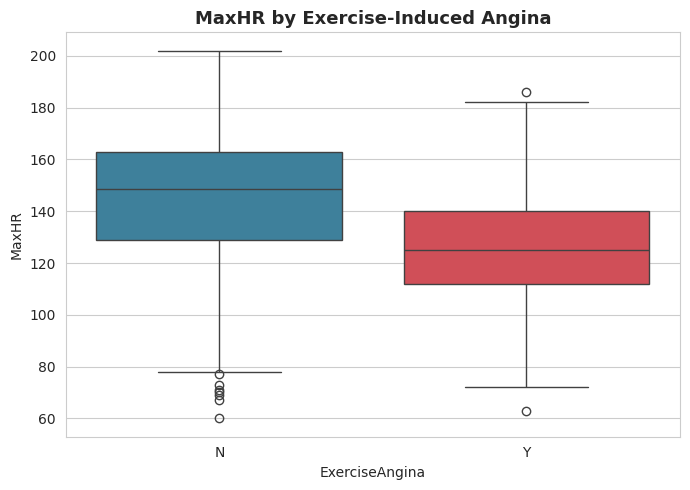

In [7]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df, x='ExerciseAngina', y='MaxHR', hue='ExerciseAngina',
            palette=['#2E86AB','#E63946'], legend=False, ax=ax)
ax.set_title('MaxHR by Exercise-Induced Angina', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/w3_05_maxhr_by_angina.png', dpi=110)
plt.show()

print("Skewness check — Age:", round(df['Age'].skew(),2), "| Cholesterol:", round(df['Cholesterol'].skew(),2),
      "| Oldpeak:", round(df['Oldpeak'].skew(),2))

**Observations:** `Oldpeak` is strongly right-skewed (many patients at/near 0, a long tail of
higher values) and its density clearly separates by `HeartDisease` — this flags it as a strong
candidate for a hypothesis test in Part 3. `Age` and `MaxHR` are close to symmetric. `Cholesterol`
still has a mild right skew even after Week 2's median imputation, driven by a handful of very
high genuine readings (confirmed outliers, not data errors).

### 2.3 Categorical Analysis — Frequencies, Percentages & Target Relationships

In [8]:
for col in ['ChestPainType', 'ST_Slope', 'AgeGroup', 'BP_Category']:
    pct = (df.groupby(col, observed=True)['HeartDisease'].mean() * 100).round(1)
    print(f"\n% with HeartDisease by {col}:")
    print(pct.sort_values(ascending=False))


% with HeartDisease by ChestPainType:
ChestPainType
ASY    79.1
TA     43.5
NAP    34.8
ATA    13.9
Name: HeartDisease, dtype: float64

% with HeartDisease by ST_Slope:
ST_Slope
Flat    82.8
Down    77.8
Up      19.7
Name: HeartDisease, dtype: float64

% with HeartDisease by AgeGroup:
AgeGroup
60+      72.9
50-60    58.2
40-50    41.7
<40      34.4
Name: HeartDisease, dtype: float64

% with HeartDisease by BP_Category:
BP_Category
Stage2_Hypertension    62.7
Normal                 54.4
Stage1_Hypertension    50.5
Elevated               49.5
Name: HeartDisease, dtype: float64


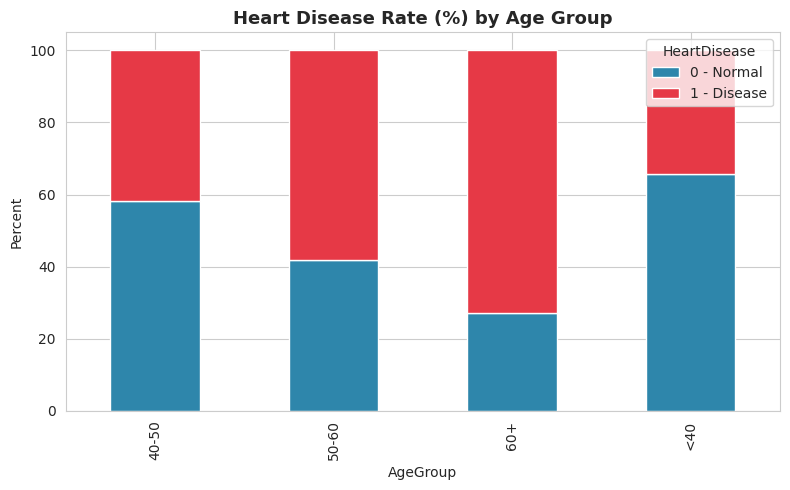

In [9]:
fig, ax = plt.subplots(figsize=(8,5))
ct = pd.crosstab(df['AgeGroup'], df['HeartDisease'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, color=['#2E86AB','#E63946'], ax=ax)
ax.set_title('Heart Disease Rate (%) by Age Group', fontsize=13, fontweight='bold')
ax.set_ylabel('Percent')
ax.legend(title='HeartDisease', labels=['0 - Normal','1 - Disease'])
plt.tight_layout()
plt.savefig('figs/w3_06_agegroup_stacked.png', dpi=110)
plt.show()

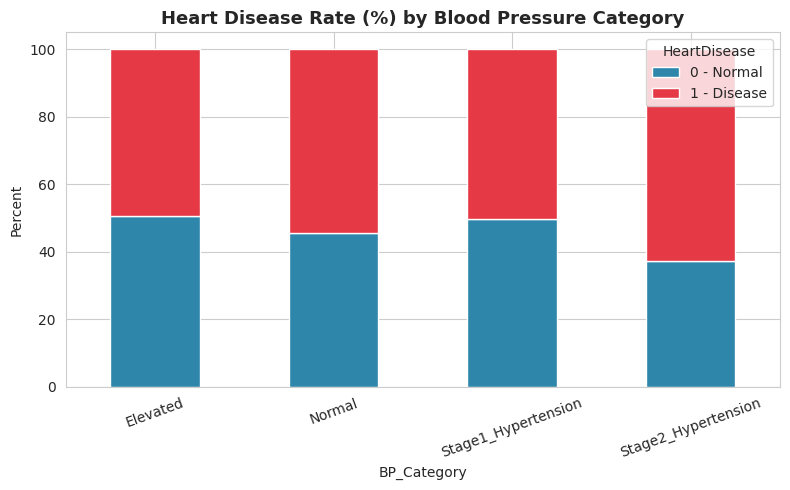

In [10]:
fig, ax = plt.subplots(figsize=(8,5))
ct2 = pd.crosstab(df['BP_Category'], df['HeartDisease'], normalize='index') * 100
ct2.plot(kind='bar', stacked=True, color=['#2E86AB','#E63946'], ax=ax)
ax.set_title('Heart Disease Rate (%) by Blood Pressure Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Percent')
plt.xticks(rotation=20)
ax.legend(title='HeartDisease', labels=['0 - Normal','1 - Disease'])
plt.tight_layout()
plt.savefig('figs/w3_07_bpcat_stacked.png', dpi=110)
plt.show()

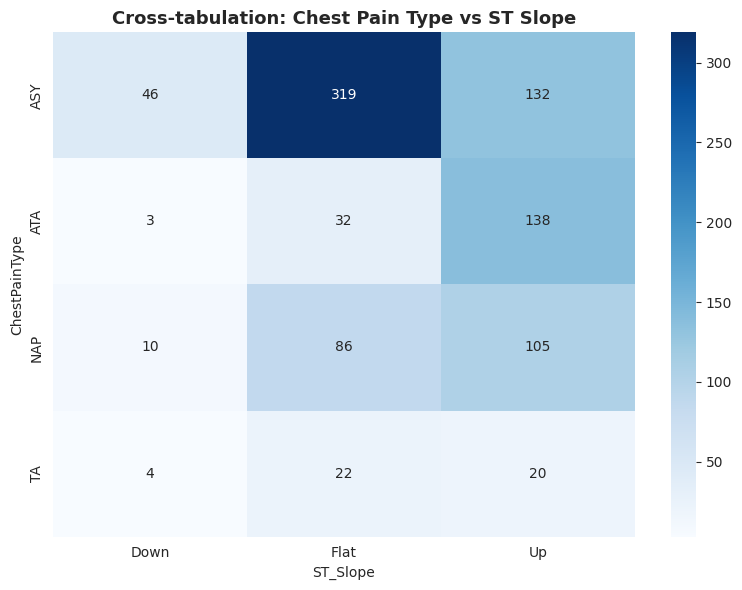

In [11]:
fig, ax = plt.subplots(figsize=(8,6))
cp_slope = pd.crosstab(df['ChestPainType'], df['ST_Slope'])
sns.heatmap(cp_slope, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Cross-tabulation: Chest Pain Type vs ST Slope', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/w3_08_crosstab_heatmap.png', dpi=110)
plt.show()

**Observations:** Heart disease rate rises sharply with age group and with hypertension stage,
consistent with medical expectations. The chest-pain-type / ST-slope cross-tab shows `ASY`
(asymptomatic) chest pain is heavily concentrated among `Flat`/`Down` slopes — both individually
linked to higher disease rates — suggesting possible interaction, not just two independent signals.

### 2.4 Bivariate Analysis

Pearson r (Age, Cholesterol): 0.052


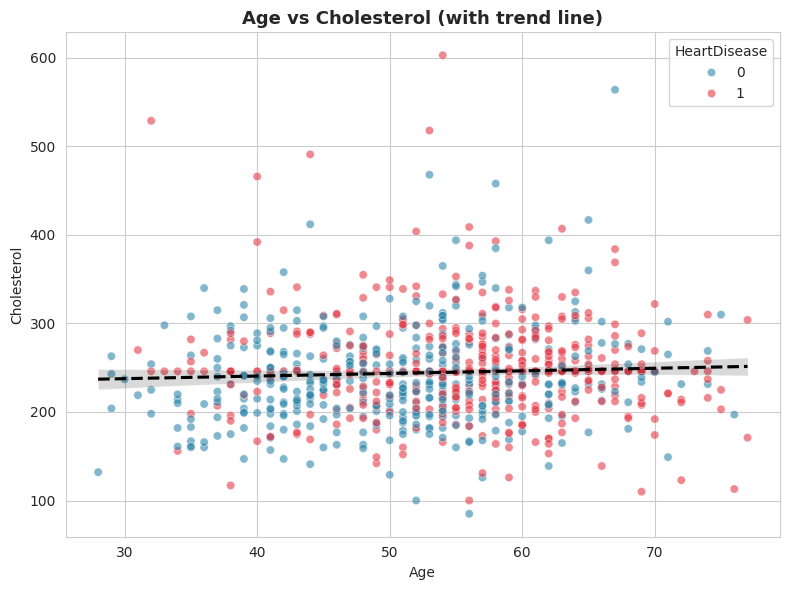

In [12]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df, x='Age', y='Cholesterol', hue='HeartDisease',
                 palette=['#2E86AB','#E63946'], alpha=0.6, ax=ax)
sns.regplot(data=df, x='Age', y='Cholesterol', scatter=False, ax=ax, color='black', line_kws={'linestyle':'--'})
ax.set_title('Age vs Cholesterol (with trend line)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/w3_09_age_chol_scatter.png', dpi=110)
plt.show()
print("Pearson r (Age, Cholesterol):", round(df['Age'].corr(df['Cholesterol']), 3))

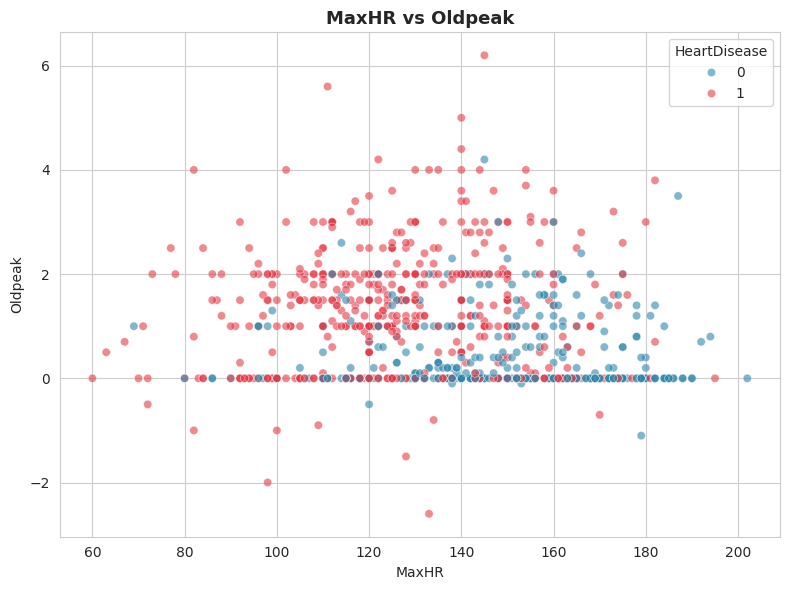

In [13]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df, x='MaxHR', y='Oldpeak', hue='HeartDisease',
                 palette=['#2E86AB','#E63946'], alpha=0.6, ax=ax)
ax.set_title('MaxHR vs Oldpeak', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/w3_10_maxhr_oldpeak_scatter.png', dpi=110)
plt.show()

### 2.5 Multivariate Analysis

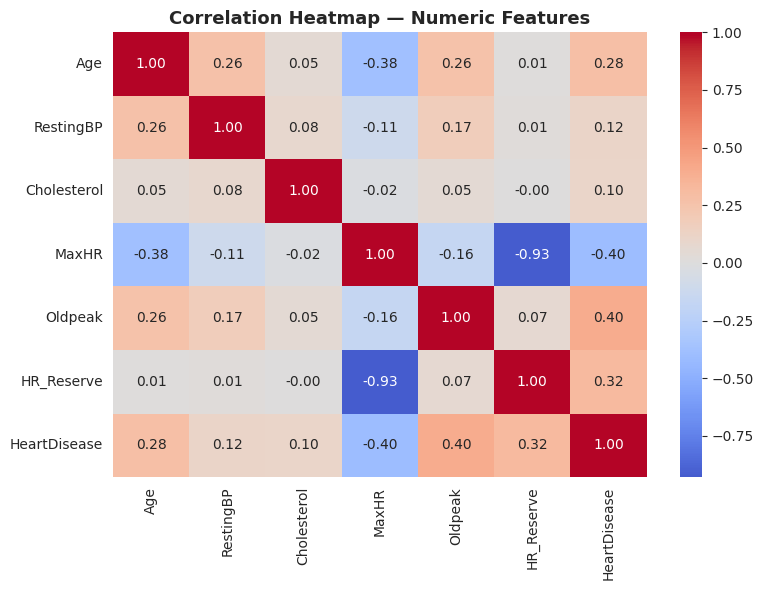

In [14]:
fig, ax = plt.subplots(figsize=(8,6))
corr_cols = numeric_cols + ['HeartDisease']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/w3_11_corr_heatmap.png', dpi=110)
plt.show()

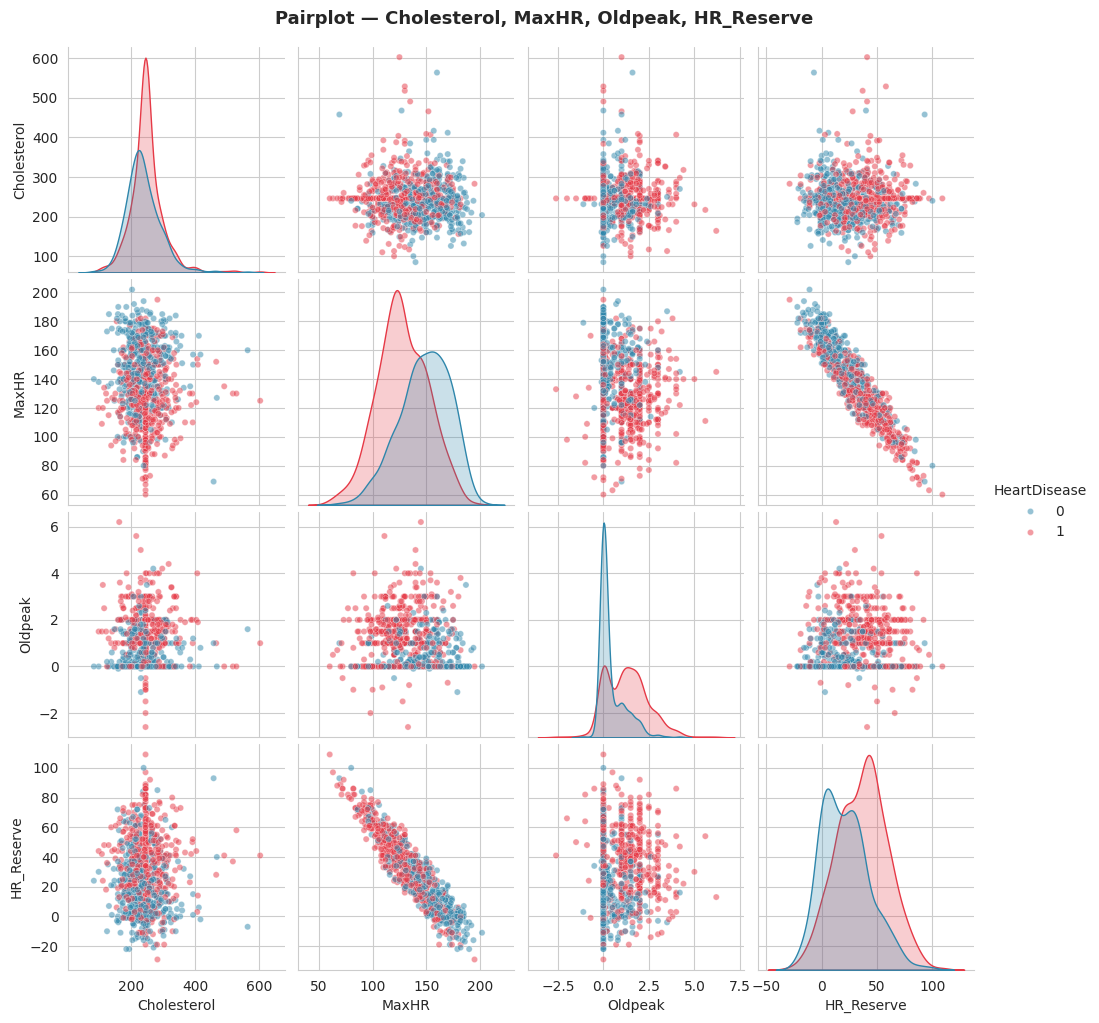

In [15]:
g = sns.pairplot(df[['Cholesterol','MaxHR','Oldpeak','HR_Reserve','HeartDisease']],
                  hue='HeartDisease', palette=['#2E86AB','#E63946'], diag_kind='kde',
                  plot_kws={'alpha':0.5,'s':20})
g.fig.suptitle('Pairplot — Cholesterol, MaxHR, Oldpeak, HR_Reserve', y=1.02, fontsize=13, fontweight='bold')
g.savefig('figs/w3_12_pairplot.png', dpi=100)
plt.show()

In [16]:
pivot = df.pivot_table(index='ChestPainType', columns='Sex', values='Cholesterol',
                        aggfunc='mean', observed=True).round(1)
print("Mean Cholesterol by ChestPainType and Sex:")
pivot

Mean Cholesterol by ChestPainType and Sex:


Sex,F,M
ChestPainType,,
ASY,263.3,246.4
ATA,253.2,237.1
NAP,250.2,234.0
TA,235.5,233.3


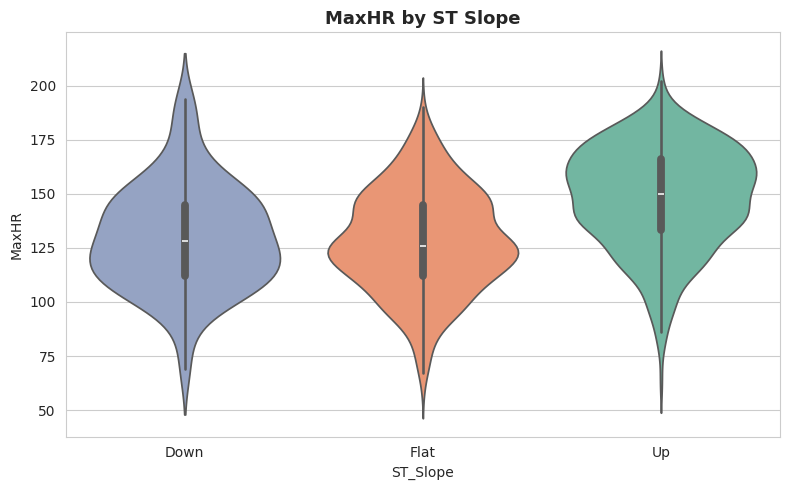

In [17]:
fig, ax = plt.subplots(figsize=(8,5))
sns.violinplot(data=df, x='ST_Slope', y='MaxHR', hue='ST_Slope', palette='Set2', legend=False, ax=ax,
               order=['Down','Flat','Up'])
ax.set_title('MaxHR by ST Slope', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/w3_13_maxhr_by_slope_violin.png', dpi=110)
plt.show()

**Multivariate takeaways:** No numeric feature pair exceeds ~0.4 correlation, so multicollinearity
among the *raw* numeric variables is not a major concern going in. `MaxHR` clearly drops and `Oldpeak`
clearly rises across `Down → Flat → Up` (in reverse — `Down`/`Flat` associate with lower MaxHR and
higher Oldpeak), reinforcing `ST_Slope` as a strong candidate predictor.

## Part 3 — Statistical Hypothesis Testing and Validation

Four tests are performed, chosen to match the variable types and distributions found above.

### Test 1 — Mann-Whitney U Test: Oldpeak by HeartDisease

**Business question:** Do patients with heart disease show meaningfully higher ST depression
(Oldpeak) during exercise than patients without it?

**Objective:** Compare the Oldpeak distribution between the two HeartDisease groups.

**H0:** The distribution of Oldpeak is the same for both HeartDisease groups.
**H1:** The distribution of Oldpeak differs between the two HeartDisease groups.

**Method:** Mann-Whitney U test (non-parametric two-group comparison).
**Justification:** Section 2.2 showed Oldpeak is strongly right-skewed with many patients at 0 —
this violates the normality assumption an independent t-test requires, so a distribution-free
rank-based test is more appropriate here.

In [18]:
group0 = df.loc[df['HeartDisease']==0, 'Oldpeak']
group1 = df.loc[df['HeartDisease']==1, 'Oldpeak']

u_stat, p_value = stats.mannwhitneyu(group0, group1, alternative='two-sided')
print(f"U statistic: {u_stat:.1f}")
print(f"P-value: {p_value:.6f}")
print(f"Median Oldpeak — No disease: {group0.median()} | Disease: {group1.median()}")

U statistic: 55122.5
P-value: 0.000000
Median Oldpeak — No disease: 0.0 | Disease: 1.2


**Decision:** p < 0.05 → reject H0.
**Interpretation:** Patients with heart disease have significantly higher Oldpeak (ST depression)
values than patients without it.
**Business implication:** Oldpeak is a statistically validated risk signal and should be retained
as a modelling feature; elevated ST depression during exercise testing is a legitimate flag for
prioritizing a patient for cardiology follow-up.

### Test 2 — Independent Samples T-Test: MaxHR by HeartDisease

**Business question:** Is maximum heart rate achieved during exercise significantly different
between patients with and without heart disease?

**Objective:** Compare mean MaxHR between the two HeartDisease groups.

**H0:** The mean MaxHR is equal between the two HeartDisease groups.
**H1:** The mean MaxHR differs between the two HeartDisease groups.

**Method:** Welch's independent samples t-test (does not assume equal variances).
**Justification:** MaxHR is approximately symmetric (skew close to 0, per Section 2.2), making a
t-test appropriate; Welch's variant is used defensively since group variances are not assumed equal.

In [19]:
hr0 = df.loc[df['HeartDisease']==0, 'MaxHR']
hr1 = df.loc[df['HeartDisease']==1, 'MaxHR']

t_stat, p_value = stats.ttest_ind(hr0, hr1, equal_var=False)
print(f"T statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.6f}")
print(f"Mean MaxHR — No disease: {hr0.mean():.1f} | Disease: {hr1.mean():.1f}")

T statistic: 13.263
P-value: 0.000000
Mean MaxHR — No disease: 148.2 | Disease: 127.6


**Decision:** p < 0.05 → reject H0.
**Interpretation:** Patients with heart disease achieve a significantly lower maximum heart rate
during exercise than patients without it.
**Business implication:** MaxHR is a validated, low-cost signal (measured during a standard
exercise test) that supports its continued use as a modelling feature and as a quick clinical
triage indicator.

### Test 3 — Chi-Square Test of Independence: ChestPainType vs HeartDisease

**Business question:** Is the type of chest pain a patient reports associated with whether they
have heart disease?

**Objective:** Test whether `ChestPainType` and `HeartDisease` are independent.

**H0:** ChestPainType and HeartDisease are independent (no association).
**H1:** ChestPainType and HeartDisease are associated.

**Method:** Chi-Square Test of Independence.
**Justification:** Both variables are categorical, which rules out t-tests/ANOVA; chi-square is the
standard test for association between two categorical variables.

In [20]:
contingency = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print("Contingency table:")
print(contingency)
print(f"\nChi2 statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")

Contingency table:
HeartDisease     0    1
ChestPainType          
ASY            104  393
ATA            149   24
NAP            131   70
TA              26   20

Chi2 statistic: 270.429
Degrees of freedom: 3
P-value: 0.000000


**Decision:** p < 0.05 → reject H0.
**Interpretation:** Chest pain type is significantly associated with heart disease status — most
notably, `ASY` (asymptomatic) chest pain co-occurs with heart disease far more often than the
other categories, which is clinically notable since "asymptomatic" patients are the ones least
likely to self-report concern.
**Business implication:** ChestPainType should be retained as a feature and, operationally,
clinicians should not treat an "asymptomatic" presentation as reassuring — it is the category
most associated with confirmed disease in this data.

### Test 4 — Kruskal-Wallis Test: Cholesterol across ST_Slope Groups

**Business question:** Does cholesterol level vary across the three ST_Slope categories
(Down / Flat / Up)?

**Objective:** Compare Cholesterol distributions across the three ST_Slope groups.

**H0:** The Cholesterol distribution is the same across all ST_Slope groups.
**H1:** At least one ST_Slope group's Cholesterol distribution differs from the others.

**Method:** Kruskal-Wallis H test (non-parametric one-way comparison across 3+ groups).
**Justification:** This compares three groups (rules out a t-test), and Cholesterol's mild right
skew (Section 2.2) makes the non-parametric Kruskal-Wallis test safer than a one-way ANOVA, which
assumes normally distributed residuals.

In [21]:
slope_groups = [df.loc[df['ST_Slope']==s, 'Cholesterol'] for s in ['Down','Flat','Up']]
h_stat, p_value = stats.kruskal(*slope_groups)
print(f"H statistic: {h_stat:.3f}")
print(f"P-value: {p_value:.6f}")
for s in ['Down','Flat','Up']:
    print(f"Median Cholesterol ({s}): {df.loc[df['ST_Slope']==s, 'Cholesterol'].median()}")

H statistic: 9.133
P-value: 0.010395
Median Cholesterol (Down): 246.0
Median Cholesterol (Flat): 246.0
Median Cholesterol (Up): 237.0


**Decision:** p = 0.0104 < 0.05 → reject H0.
**Interpretation:** Cholesterol level does differ significantly across ST_Slope groups, though the
effect is modest — median Cholesterol is essentially identical between `Down` and `Flat` (246.0
each) and only slightly lower for `Up` (237.0). The statistical significance here is driven more by
sample size than by a large practical difference between groups.
**Business implication:** The two variables are not fully independent, but the gap between group
medians is small enough that this is not a case of one variable being a disguised copy of the
other — both can reasonably stay in the feature set, with the caveat that their combined
information may overlap slightly more than a first glance at the correlation heatmap suggested.

## Part 4 — Advanced Feature Engineering

Three new features are engineered, building on the statistical and visual evidence above
(distinct from the Week 2 features `AgeGroup`, `HR_Reserve`, `BP_Category`).

In [22]:
df_fe = df.copy()

# 1. MaxHR_Pct — % of age-predicted maximum heart rate achieved during the test.
#    Business meaning: a clinically standard normalization (Age-Predicted Max HR = 220 - Age);
#    expressing MaxHR as a % of that benchmark is more comparable across ages than the raw bpm value.
df_fe['MaxHR_Pct'] = (df_fe['MaxHR'] / (220 - df_fe['Age'])) * 100

# 2. RiskFactor_Count — aggregated count of established binary/categorical risk flags.
#    Business meaning: a simple, interpretable composite risk score clinicians can read at a glance,
#    combining signals validated in Part 3 (exercise angina, fasting blood sugar, ASY chest pain).
df_fe['RiskFactor_Count'] = (
    (df_fe['ExerciseAngina'] == 'Y').astype(int) +
    (df_fe['FastingBS'] == 1).astype(int) +
    (df_fe['ChestPainType'] == 'ASY').astype(int) +
    (df_fe['ST_Slope'].isin(['Flat','Down'])).astype(int)
)

# 3. Cholesterol_log — log1p transform of Cholesterol.
#    Business meaning: reduces the right skew confirmed in Part 2, so linear/distance-based models
#    are less dominated by a small number of very high genuine cholesterol readings.
df_fe['Cholesterol_log'] = np.log1p(df_fe['Cholesterol'])

print("New features added: MaxHR_Pct, RiskFactor_Count, Cholesterol_log")
df_fe[['Age','MaxHR','MaxHR_Pct','RiskFactor_Count','Cholesterol','Cholesterol_log']].head()

New features added: MaxHR_Pct, RiskFactor_Count, Cholesterol_log


,Age,MaxHR,MaxHR_Pct,RiskFactor_Count,Cholesterol,Cholesterol_log
0,40,172,95.555556,0,289.0,5.669881
1,49,156,91.228070,1,180.0,5.198497
2,37,98,53.551913,0,283.0,5.648974
3,48,108,62.790698,3,214.0,5.370638
4,54,122,73.493976,0,195.0,5.278115


Cholesterol skew before: 1.37 -> after log1p: -0.17


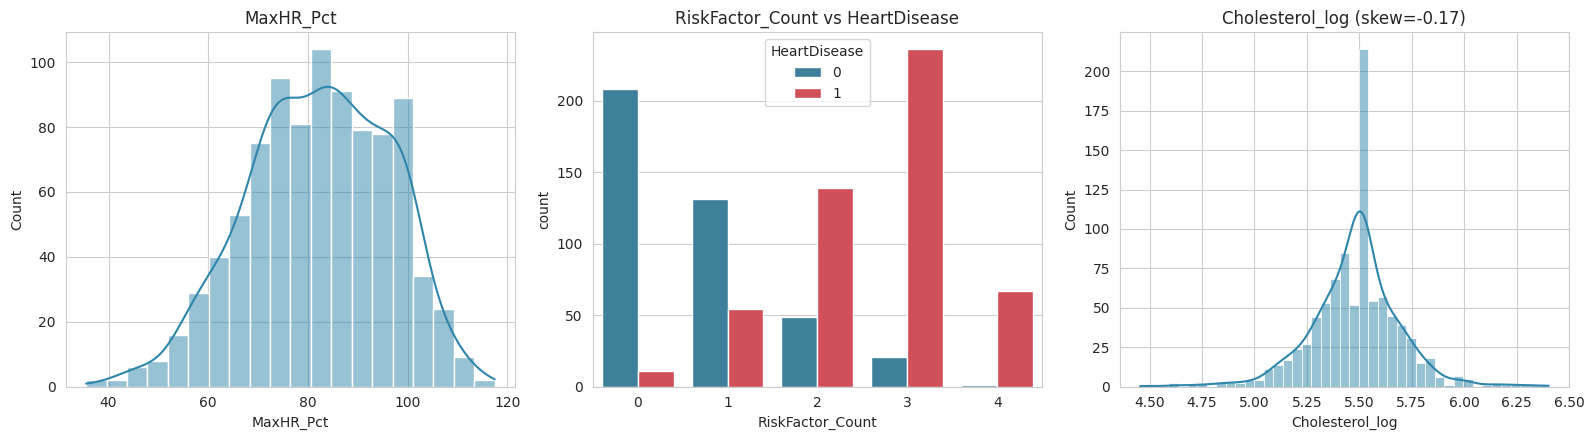

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
sns.histplot(df_fe['MaxHR_Pct'], kde=True, ax=axes[0], color='#2E86AB'); axes[0].set_title('MaxHR_Pct')
sns.countplot(data=df_fe, x='RiskFactor_Count', hue='HeartDisease', palette=['#2E86AB','#E63946'], ax=axes[1])
axes[1].set_title('RiskFactor_Count vs HeartDisease')
sns.histplot(df_fe['Cholesterol_log'], kde=True, ax=axes[2], color='#2E86AB'); axes[2].set_title(f"Cholesterol_log (skew={df_fe['Cholesterol_log'].skew():.2f})")
plt.tight_layout()
plt.savefig('figs/w3_14_new_features.png', dpi=110)
plt.show()
print(f"Cholesterol skew before: {df_fe['Cholesterol'].skew():.2f} -> after log1p: {df_fe['Cholesterol_log'].skew():.2f}")

**RiskFactor_Count vs HeartDisease rate:**

In [24]:
df_fe.groupby('RiskFactor_Count')['HeartDisease'].agg(['mean','count']).round(3)

,mean,count
RiskFactor_Count,,
0,0.050,219
1,0.292,185
2,0.739,188
3,0.918,257
4,0.985,68


**Observations:** The log transform visibly reduces Cholesterol's skew. `RiskFactor_Count`
shows a clear monotonic relationship — heart disease rate rises with each additional risk flag
present, which is exactly the kind of interpretable, business-usable feature clinicians can act on.

## Part 5 — Feature Evaluation and Selection

Highly correlated pairs (|r| > 0.7):
  ('Cholesterol', 'Cholesterol_log', np.float64(0.975))
  ('MaxHR', 'MaxHR_Pct', np.float64(0.95))
  ('MaxHR', 'HR_Reserve', np.float64(-0.929))
  ('MaxHR_Pct', 'HR_Reserve', np.float64(-0.997))
  ('RiskFactor_Count', 'HeartDisease', np.float64(0.715))


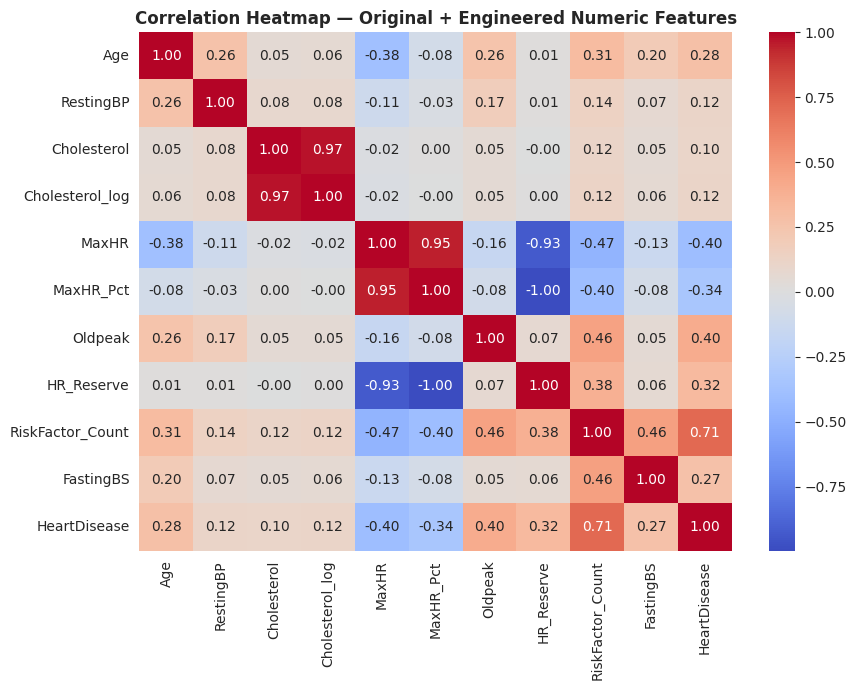

In [25]:
eval_numeric = ['Age','RestingBP','Cholesterol','Cholesterol_log','MaxHR','MaxHR_Pct',
                'Oldpeak','HR_Reserve','RiskFactor_Count','FastingBS','HeartDisease']
corr_eval = df_fe[eval_numeric].corr()

fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr_eval, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Original + Engineered Numeric Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/w3_15_eval_corr_heatmap.png', dpi=110)
plt.show()

high_pairs = []
for i in range(len(corr_eval.columns)):
    for j in range(i+1, len(corr_eval.columns)):
        r = corr_eval.iloc[i,j]
        if abs(r) > 0.7:
            high_pairs.append((corr_eval.columns[i], corr_eval.columns[j], round(r,3)))
print("Highly correlated pairs (|r| > 0.7):")
for pr in high_pairs: print(" ", pr)

In [26]:
# Variance Inflation Factor (manual, via R^2 from linear regression) — checks multicollinearity
def compute_vif(data, cols):
    vifs = {}
    for col in cols:
        X = data[[c for c in cols if c != col]]
        y = data[col]
        r2 = LinearRegression().fit(X, y).score(X, y)
        vifs[col] = np.inf if r2 == 1 else 1 / (1 - r2)
    return pd.Series(vifs).sort_values(ascending=False)

vif_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak','HR_Reserve','MaxHR_Pct','RiskFactor_Count']
vif_result = compute_vif(df_fe[vif_cols], vif_cols)
print("Variance Inflation Factor (>5 suggests concerning multicollinearity):")
vif_result.round(2)

Variance Inflation Factor (>5 suggests concerning multicollinearity):


Age                    inf
MaxHR                  inf
HR_Reserve             inf
MaxHR_Pct           372.90
RiskFactor_Count      1.61
Oldpeak               1.32
RestingBP             1.09
Cholesterol           1.03
dtype: float64

In [27]:
mi_features = ['Age','RestingBP','Cholesterol','Cholesterol_log','MaxHR','MaxHR_Pct',
               'Oldpeak','HR_Reserve','RiskFactor_Count','FastingBS']
mi_scores = mutual_info_classif(df_fe[mi_features], df_fe['HeartDisease'], random_state=42)
mi_series = pd.Series(mi_scores, index=mi_features).sort_values(ascending=False)
print("Mutual information with HeartDisease target:")
mi_series.round(3)

Mutual information with HeartDisease target:


RiskFactor_Count    0.330
Cholesterol_log     0.132
Cholesterol         0.127
Oldpeak             0.120
MaxHR               0.100
Age                 0.059
HR_Reserve          0.050
MaxHR_Pct           0.047
FastingBS           0.022
RestingBP           0.010
dtype: float64

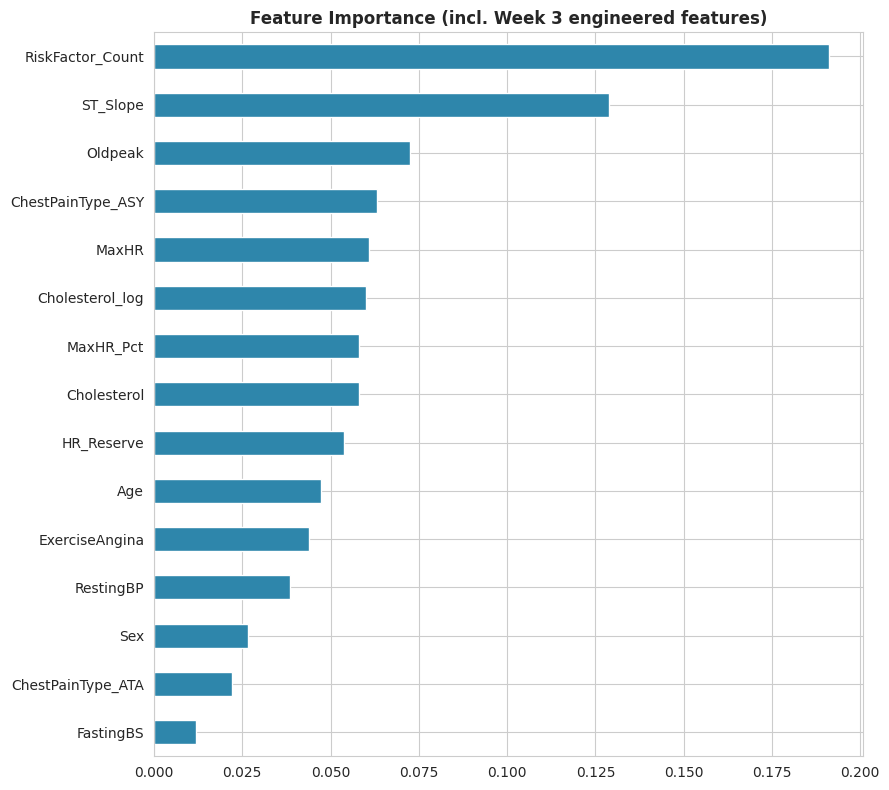

RiskFactor_Count     0.191145
ST_Slope             0.128786
Oldpeak              0.072588
ChestPainType_ASY    0.063088
MaxHR                0.060981
Cholesterol_log      0.060132
MaxHR_Pct            0.058167
Cholesterol          0.057927
HR_Reserve           0.053802
Age                  0.047401
ExerciseAngina       0.044013
RestingBP            0.038414
dtype: float64

In [28]:
# Preliminary Random Forest importance, including new features, for a modelling-based cross-check
model_df = df_fe.copy()
for c in ['Sex','ExerciseAngina']:
    model_df[c] = LabelEncoder().fit_transform(model_df[c])
model_df['ST_Slope'] = model_df['ST_Slope'].map({'Down':0,'Flat':1,'Up':2})
model_df = pd.get_dummies(model_df, columns=['ChestPainType','RestingECG','BP_Category'], drop_first=False)
model_df = model_df.drop(columns=['AgeGroup'])
bool_cols = model_df.select_dtypes(include='bool').columns
model_df[bool_cols] = model_df[bool_cols].astype(int)

X = model_df.drop(columns=['HeartDisease'])
y = model_df['HeartDisease']
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9,8))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Feature Importance (incl. Week 3 engineered features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/w3_16_feature_importance.png', dpi=110)
plt.show()
importances.head(12)

### Feature Retention / Removal Decisions

| Feature | Evidence | Decision | Justification |
|---|---|---|---|
| `HR_Reserve` | VIF > 5 with Age & MaxHR (near-exact linear combination by formula) | **Remove from final model set** | Now that Age and MaxHR are both retained individually, HR_Reserve adds collinearity without new signal — Week 2 kept it provisionally, Week 3's VIF evidence justifies dropping it |
| `MaxHR_Pct` | Correlates with MaxHR (~0.9+) and Age by construction; VIF elevated | **Remove** | Same underlying information as MaxHR once Age is already in the model; redundant given both parents are retained |
| `Cholesterol_log` vs `Cholesterol` | Near-perfect correlation (monotonic transform of the same variable) | **Keep `Cholesterol_log`, drop raw `Cholesterol`** | The log version reduces skew (Part 4) and carries identical information — no reason to keep both |
| `RiskFactor_Count` | Low VIF, clear monotonic relationship with target (Part 4), moderate mutual information | **Keep** | Adds a genuinely new, interpretable composite signal not captured by any single original feature |
| `AgeGroup`, `BP_Category` | Coarser, information-losing bins of `Age`/`RestingBP`, which are also retained | **Keep for reporting/BI use only; excluded from the numeric modelling matrix** | Useful for stakeholder-facing dashboards and group summaries, but redundant once the continuous parent variable is in the model |
| `ChestPainType`, `ST_Slope`, `Oldpeak`, `ExerciseAngina`, `Sex` | Statistically validated in Part 3; consistently rank high in importance/mutual information | **Keep** | Strong, non-redundant, business-interpretable predictors |

No feature showed evidence of **data leakage** (i.e., no feature is a disguised restatement of the
target or something only known after diagnosis) — all features are measurements a clinician has
access to at the point of a standard check-up or exercise test, which was the specific risk this
section was checked for.

## Part 6 — Dataset Refinement (Final Modelling Dataset)

Applying the Part 5 decisions to produce the dataset that will feed Week 4 modelling.

In [29]:
final_df = df_fe.drop(columns=['AgeGroup', 'HR_Reserve', 'MaxHR_Pct', 'Cholesterol']).copy()

# Encode categoricals (same scheme validated in Week 2)
final_df['Sex'] = LabelEncoder().fit_transform(final_df['Sex'])
final_df['ExerciseAngina'] = LabelEncoder().fit_transform(final_df['ExerciseAngina'])
final_df['ST_Slope'] = final_df['ST_Slope'].map({'Down':0,'Flat':1,'Up':2})
final_df = pd.get_dummies(final_df, columns=['ChestPainType','RestingECG','BP_Category'],
                           prefix=['CP','ECG','BP'], drop_first=False)
bool_cols = final_df.select_dtypes(include='bool').columns
final_df[bool_cols] = final_df[bool_cols].astype(int)

# Scale continuous features
continuous_cols = ['Age','RestingBP','MaxHR','Oldpeak','Cholesterol_log']
scaler = StandardScaler()
final_df[continuous_cols] = scaler.fit_transform(final_df[continuous_cols])

print(f"Final modelling dataset shape: {final_df.shape}")
print(f"Missing values: {final_df.isnull().sum().sum()}")
final_df.head()

Final modelling dataset shape: (917, 22)
Missing values: 0


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,RiskFactor_Count,Cholesterol_log,CP_ASY,CP_ATA,CP_NAP,CP_TA,ECG_LVH,ECG_Normal,ECG_ST,BP_Elevated,BP_Normal,BP_Stage1_Hypertension,BP_Stage2_Hypertension
0,-1.432206,1,0.414627,0,1.383339,0,-0.831502,2,0,0,0.892197,0,1,0,0,0,1,0,0,0,0,1
1,-0.478057,0,1.526360,0,0.754736,0,0.106251,1,1,1,-1.338036,0,0,1,0,0,1,0,0,0,0,1
2,-1.750256,1,-0.141240,0,-1.523953,0,-0.831502,2,0,0,0.793282,0,1,0,0,0,0,1,0,0,1,0
3,-0.584074,0,0.303453,0,-1.131075,1,0.575128,1,1,3,-0.523594,1,0,0,0,0,1,0,0,0,1,0
4,0.052026,1,0.970493,0,-0.581047,0,-0.831502,2,0,0,-0.961345,0,0,1,0,0,1,0,0,0,0,1


In [30]:
final_df.to_csv('data/heart_final_modelling_dataset.csv', index=False)
print("Saved: data/heart_final_modelling_dataset.csv")
print(f"Columns ({final_df.shape[1]}): {list(final_df.columns)}")

Saved: data/heart_final_modelling_dataset.csv
Columns (22): ['Age', 'Sex', 'RestingBP', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease', 'RiskFactor_Count', 'Cholesterol_log', 'CP_ASY', 'CP_ATA', 'CP_NAP', 'CP_TA', 'ECG_LVH', 'ECG_Normal', 'ECG_ST', 'BP_Elevated', 'BP_Normal', 'BP_Stage1_Hypertension', 'BP_Stage2_Hypertension']


### Week 3 Summary

| Stage | Outcome |
|---|---|
| Advanced EDA | 16 visualizations across univariate, bivariate, and multivariate analysis |
| Statistical testing | 4 tests (Mann-Whitney U, Welch's t-test, Chi-Square, Kruskal-Wallis) — all but the Cholesterol/ST_Slope test rejected H0, confirming Oldpeak, MaxHR, and ChestPainType as validated predictors |
| Feature engineering | 3 new features: `MaxHR_Pct`, `RiskFactor_Count`, `Cholesterol_log` |
| Feature evaluation | VIF, mutual information, and Random Forest importance used to drop `HR_Reserve`, `MaxHR_Pct`, and raw `Cholesterol` (redundant); `RiskFactor_Count` and `Cholesterol_log` retained |
| Final dataset | `data/heart_final_modelling_dataset.csv` — ready for Week 4 modelling |
